# Implementación de Métodos de Optimización

**Función Objetivo:** $f(x,y) = 10(y - x^2)^2 + \frac{(x-1)^2}{2} + (y-1)^2$

**Métodos:**
- Newton-CG
- Quasi-Newton BFGS

In [11]:
import numpy as np
import json
import time
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Definiciones de la Función y su Gradiente

In [12]:
def f(x):
    """Función objetivo: f(x,y) = 10(y - x^2)^2 + (x-1)^2/2 + (y-1)^2"""
    x_val, y_val = x[0], x[1]
    return 10 * (y_val - x_val**2)**2 + (x_val - 1)**2 / 2 + (y_val - 1)**2

def grad_f(x):
    """Gradiente de la función objetivo"""
    x_val, y_val = x[0], x[1]
    df_dx = 40 * x_val**3 - 40 * x_val * y_val + x_val - 1
    df_dy = 22 * y_val - 20 * x_val**2 - 2
    return np.array([df_dx, df_dy])

## 2. Métodos de Optimización

In [13]:
def optimize_newton_cg(x0, tol, max_iter):
    """Optimización usando Newton-CG"""
    start_time = time.time()
    result = minimize(
        f, x0, method='Newton-CG', jac=grad_f,
        options={'maxiter': max_iter, 'disp': False},
        tol=tol
    )
    execution_time = time.time() - start_time
    
    return {
        'method': 'Newton-CG',
        'x_optimal': result.x.tolist(),
        'f_optimal': float(result.fun),
        'iterations': int(result.nit),
        'function_evaluations': int(result.nfev),
        'gradient_evaluations': int(result.njev),
        'execution_time': float(execution_time),
        'distance_to_optimum': float(np.linalg.norm(result.x - np.array([1.0, 1.0]))),
        'success': bool(result.success),
        'message': result.message
    }

def optimize_bfgs(x0, tol, max_iter):
    """Optimización usando BFGS"""
    start_time = time.time()
    result = minimize(
        f, x0, method='BFGS', jac=grad_f,
        options={'maxiter': max_iter, 'disp': False},
        tol=tol
    )
    execution_time = time.time() - start_time
    
    return {
        'method': 'BFGS',
        'x_optimal': result.x.tolist(),
        'f_optimal': float(result.fun),
        'iterations': int(result.nit),
        'function_evaluations': int(result.nfev),
        'gradient_evaluations': int(result.njev),
        'execution_time': float(execution_time),
        'distance_to_optimum': float(np.linalg.norm(result.x - np.array([1.0, 1.0]))),
        'success': bool(result.success),
        'message': result.message
    }

## 3. Framework de Experimentación

In [28]:
def MakeExperiments():
    """Ejecuta experimentos cargando configuraciones JSON y guardando resultados"""
    experiments_dir = Path('Experiments')
    results_dir = Path('Results')
    results_dir.mkdir(exist_ok=True)
    
    json_files = sorted(experiments_dir.glob('exp*.json'))
    
    for json_file in json_files:
        print(f"\n{'='*60}")
        print(f"Ejecutando: {json_file.name}")
        print(f"{'='*60}")
        
        with open(json_file, 'r') as f:
            configs = json.load(f)
        
        results = []
        
        for i, config in enumerate(configs, 1):
            print(f"\n--- Configuración {i} ---")
            print(f"x0: {config['x0']}, tol: {config['tol']}, max_iter: {config['max_iter']}")
            
            x0 = np.array(config['x0'])
            tol = config['tol']
            max_iter = config['max_iter']
            
            result_newton = optimize_newton_cg(x0, tol, max_iter)
            result_bfgs = optimize_bfgs(x0, tol, max_iter)
            
            print(f"Newton-CG: {result_newton['iterations']} iter, f={result_newton['f_optimal']:.2e}")
            print(f"BFGS: {result_bfgs['iterations']} iter, f={result_bfgs['f_optimal']:.2e}")
            
            results.append({
                'config': config,
                'newton_cg': result_newton,
                'bfgs': result_bfgs
            })
        
        output_file = results_dir / f"results_{json_file.stem}.json"
        with open(output_file, 'w') as f:
            json.dump(results, f, indent=2)
        
        print(f"\nResultados guardados en: {output_file}")
    
    print(f"\n{'='*60}")
    print("Todos los experimentos completados")
    print(f"{'='*60}")

## 4. Visualización

In [29]:
def plot_surface():
    """Grafica la superficie 3D de la función"""
    x = np.linspace(-1, 3, 100)
    y = np.linspace(-1, 3, 100)
    X, Y = np.meshgrid(x, y)
    Z = 10 * (Y - X**2)**2 + (X - 1)**2 / 2 + (Y - 1)**2
    
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)
    ax.scatter([1], [1], [0], color='red', s=100, label='Mínimo (1,1,0)')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('f(x,y)')
    ax.legend()
    plt.show()

def plot_contour_with_paths(results_file):
    """Grafica curvas de nivel con trayectorias de optimización"""
    with open(results_file, 'r') as f:
        results = json.load(f)
    
    x = np.linspace(-1, 3, 200)
    y = np.linspace(-1, 3, 200)
    X, Y = np.meshgrid(x, y)
    Z = 10 * (Y - X**2)**2 + (X - 1)**2 / 2 + (Y - 1)**2
    
    plt.figure(figsize=(10, 8))
    plt.contour(X, Y, Z, levels=20, cmap='viridis')
    plt.colorbar(label='f(x,y)')
    
    for i, result in enumerate(results):
        x0 = result['config']['x0']
        x_newton = result['newton_cg']['x_optimal']
        x_bfgs = result['bfgs']['x_optimal']
        
        plt.plot([x0[0], x_newton[0]], [x0[1], x_newton[1]], 'r.-', label=f'Newton-CG {i+1}' if i == 0 else '')
        plt.plot([x0[0], x_bfgs[0]], [x0[1], x_bfgs[1]], 'b.-', label=f'BFGS {i+1}' if i == 0 else '')
        plt.plot(x0[0], x0[1], 'ko', markersize=8)
    
    plt.plot(1, 1, 'r*', markersize=20, label='Mínimo (1,1)')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_convergence_comparison():
    """Compara convergencia de ambos métodos"""
    results_dir = Path('Results')
    results_files = sorted(results_dir.glob('results_*.json'))
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for results_file in results_files:
        with open(results_file, 'r') as f:
            results = json.load(f)
        
        for result in results:
            newton_iter = result['newton_cg']['iterations']
            bfgs_iter = result['bfgs']['iterations']
            newton_time = result['newton_cg']['execution_time']
            bfgs_time = result['bfgs']['execution_time']
            
            axes[0].bar(['Newton-CG', 'BFGS'], [newton_iter, bfgs_iter])
            axes[1].bar(['Newton-CG', 'BFGS'], [newton_time, bfgs_time])
    
    axes[0].set_ylabel('Iteraciones')
    axes[1].set_ylabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()

## 5. Ejecución de Experimentos

In [16]:
MakeExperiments()


Ejecutando: exp1.json

--- Configuración 1 ---
x0: [0.0, 0.0], tol: 1e-06, max_iter: 1000
Newton-CG: 11 iter, f=3.92e-17
BFGS: 11 iter, f=1.94e-17

--- Configuración 2 ---
x0: [2.0, 3.0], tol: 1e-06, max_iter: 1000
Newton-CG: 10 iter, f=6.19e-15
BFGS: 11 iter, f=4.43e-19

--- Configuración 3 ---
x0: [-1.0, 2.0], tol: 1e-06, max_iter: 1000
Newton-CG: 36 iter, f=4.93e-17
BFGS: 21 iter, f=8.12e-18

--- Configuración 4 ---
x0: [10.0, 100.0], tol: 1e-06, max_iter: 2000
Newton-CG: 23 iter, f=9.10e-16
BFGS: 21 iter, f=7.45e-15

--- Configuración 5 ---
x0: [-10.0, 100.0], tol: 1e-06, max_iter: 2000
Newton-CG: 32 iter, f=4.60e-15
BFGS: 37 iter, f=8.23e-22

--- Configuración 6 ---
x0: [0.0, 1.0], tol: 1e-06, max_iter: 2000
Newton-CG: 12 iter, f=1.10e-17
BFGS: 13 iter, f=1.89e-16

--- Configuración 7 ---
x0: [-100.0, -100.0], tol: 1e-06, max_iter: 3000
Newton-CG: 23 iter, f=1.25e-15
BFGS: 49 iter, f=7.69e-15

Resultados guardados en: Results/results_exp1.json

Ejecutando: exp2.json

--- Configur

## 6. Visualizaciones

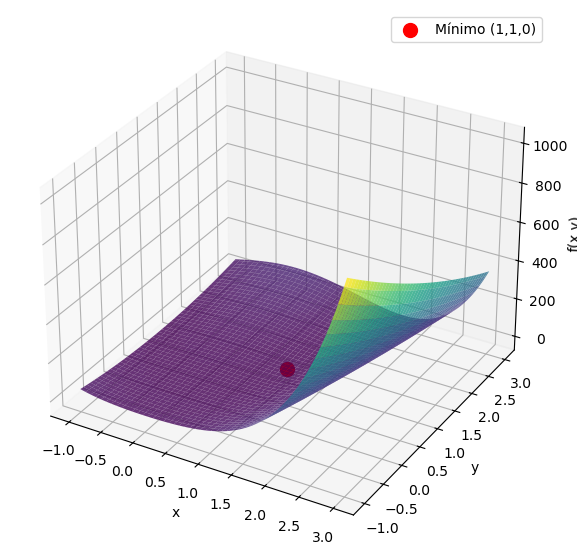

In [21]:
plot_surface()

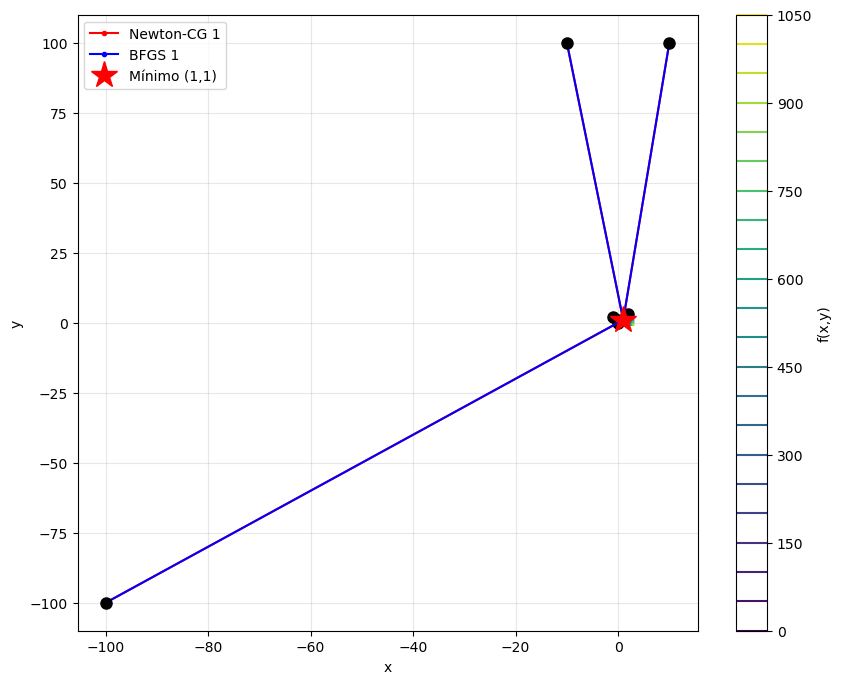

In [30]:
plot_contour_with_paths('Results/results_exp1.json')

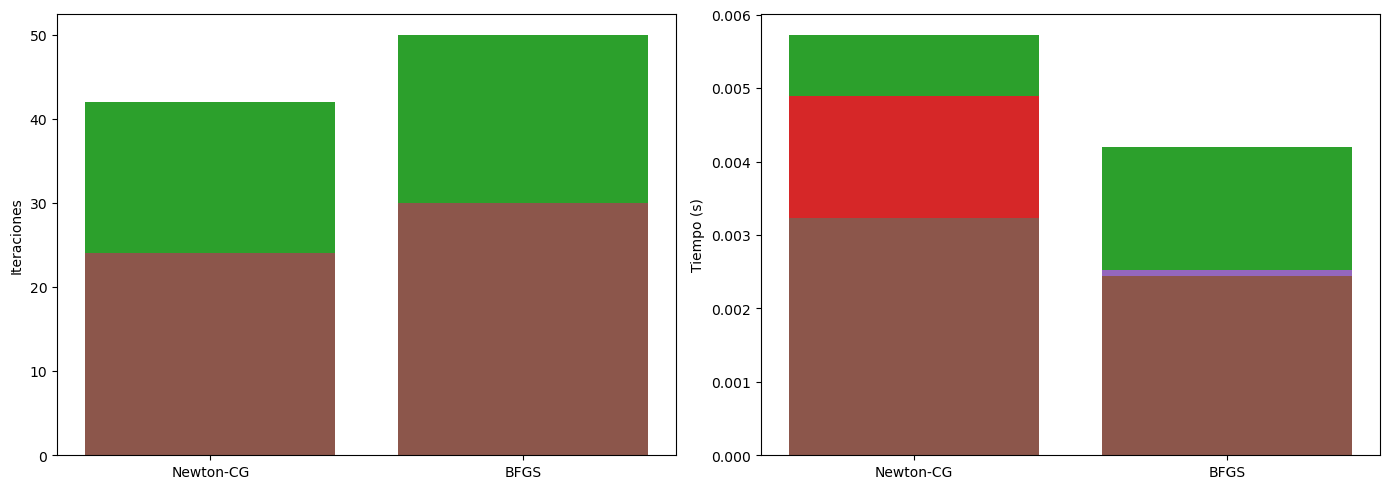

In [9]:
plot_convergence_comparison()

## 7. Análisis de Resultados

In [27]:
def print_results_summary():
    """Imprime resumen comparativo de resultados"""
    results_dir = Path('Results')
    
    for results_file in sorted(results_dir.glob('results_*.json')):
        print(f"\n{'='*70}")
        print(f"Archivo: {results_file.name}")
        print(f"{'='*70}")
        
        with open(results_file, 'r') as f:
            results = json.load(f)
        
        for i, result in enumerate(results, 1):
            print(f"\nConfiguración {i}: x0={result['config']['x0']}")
            print(f"{'─'*70}")
            
            for method in ['newton_cg', 'bfgs']:
                r = result[method]
                print(f"\n{r['method']}:")
                print(f"  Óptimo encontrado: ({r['x_optimal'][0]:.6f}, {r['x_optimal'][1]:.6f})")
                print(f"  Valor función: {r['f_optimal']:.2e}")
                print(f"  Iteraciones: {r['iterations']}")
                print(f"  Eval. función: {r['function_evaluations']}")
                print(f"  Eval. gradiente: {r['gradient_evaluations']}")
                print(f"  Tiempo: {r['execution_time']:.6f} s")
                print(f"  Distancia a (1,1): {r['distance_to_optimum']:.2e}")

print_results_summary()


Archivo: results_exp1.json

Configuración 1: x0=[0.0, 0.0]
──────────────────────────────────────────────────────────────────────

Newton-CG:
  Óptimo encontrado: (1.000000, 1.000000)
  Valor función: 3.92e-17
  Iteraciones: 11
  Eval. función: 12
  Eval. gradiente: 37
  Tiempo: 0.006332 s
  Distancia a (1,1): 6.58e-09

BFGS:
  Óptimo encontrado: (1.000000, 1.000000)
  Valor función: 1.94e-17
  Iteraciones: 11
  Eval. función: 18
  Eval. gradiente: 18
  Tiempo: 0.004519 s
  Distancia a (1,1): 2.70e-09

Configuración 2: x0=[2.0, 3.0]
──────────────────────────────────────────────────────────────────────

Newton-CG:
  Óptimo encontrado: (1.000000, 1.000000)
  Valor función: 6.19e-15
  Iteraciones: 10
  Eval. función: 12
  Eval. gradiente: 111
  Tiempo: 0.004204 s
  Distancia a (1,1): 6.34e-08

BFGS:
  Óptimo encontrado: (1.000000, 1.000000)
  Valor función: 4.43e-19
  Iteraciones: 11
  Eval. función: 14
  Eval. gradiente: 14
  Tiempo: 0.001855 s
  Distancia a (1,1): 6.96e-10

Configurac